In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [12]:
housing = fetch_california_housing()
data= pd.DataFrame(housing.data,columns=housing.feature_names)
data["Price"]=housing.target

In [27]:
X=data[['AveRooms']].values
y=data['Price'].values

In [28]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [31]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [69]:
w=0
b=0
learning_rate=0.01
epochs=1000
cost_history=[]

n=len(X_train_scaled)
for i in range(epochs):
    y_pred=w * X_train_scaled.flatten()+b
    cost=(1/(2*n)) * np.sum((y_pred -y_train)**2)
    cost_history.append(cost)
    dw=(1/n)* np.sum((y_pred -y_train) *X_train_scaled.flatten())
    db=(1/n) * np.sum(y_pred -y_train)
    w=w-learning_rate*dw
    b=b-learning_rate*db
    if i % 100==0:
        
        print(f"Epoch{i}, Cost={cost:.4f}")
y_pred_gd=w*X_test_scaled.flatten()+b        
    

Epoch0, Cost=2.8149
Epoch100, Cost=0.9414
Epoch200, Cost=0.6904
Epoch300, Cost=0.6568
Epoch400, Cost=0.6523
Epoch500, Cost=0.6517
Epoch600, Cost=0.6516
Epoch700, Cost=0.6516
Epoch800, Cost=0.6516
Epoch900, Cost=0.6516


In [71]:
print("Gradient Descent")
print("----------------")
print("Weight:", w)
print("Bias:", b)
print("MSE:", mean_squared_error(y_test,y_pred_gd))
print("R2 Score:", r2_score(y_test,y_pred_gd))

Gradient Descent
----------------
Weight: 0.18323090648660517
Bias: 2.0718574888450205
MSE: 1.292327655590046
R2 Score: 0.013798228607320828


In [72]:
X_train_ne = np.c_[np.ones((len(X_train),1)), X_train]
X_test_ne=np.c_[np.ones((len(X_test),1)),X_test]
theta=np.linalg.inv(X_train_ne.T @ X_train_ne) @ X_train_ne.T @ y_train
y_pred_ne=X_test_ne @ theta



In [73]:
print("Normal Equation")
print("----------------")
print("Intercept",theta[0])
print("Slope",theta[1])
print("MSE:", mean_squared_error(y_test,y_pred_ne))
print("R2 Score:",r2_score(y_test,y_pred_ne))

Normal Equation
----------------
Intercept 1.6547622685968417
Slope 0.07675558963126736
MSE: 1.2923314440807299
R2 Score: 0.013795337532284901


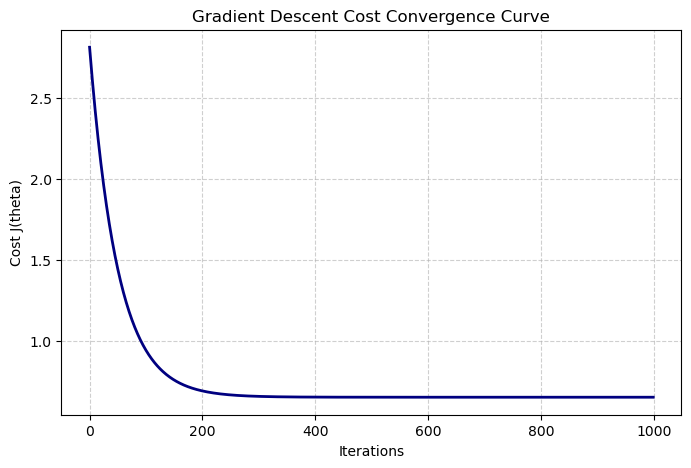

In [78]:
plt.figure(figsize=(8,5))
plt.plot(cost_history,color='navy',linewidth=2)
plt.title('Gradient Descent Cost Convergence Curve')
plt.xlabel('Iterations')
plt.ylabel('Cost J(theta)')
plt.grid(True,linestyle='--' ,alpha=0.6)
plt.show()

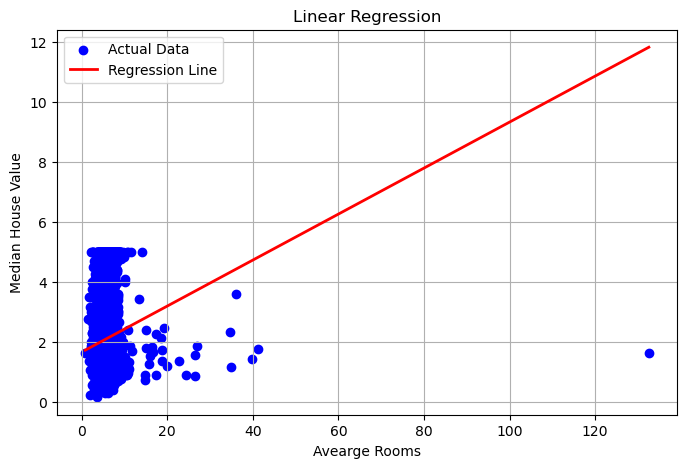

In [79]:
index=np.argsort(X_test.flatten())
plt.figure(figsize=(8,5))
plt.scatter(X_test,y_test,color='blue',label='Actual Data')
plt.plot(
    X_test.flatten()[index],
    y_pred_ne[index],
    color='red',
    linewidth=2,
    label='Regression Line'
)
plt.title("Linear Regression")
plt.xlabel("Avearge Rooms")
plt.ylabel("Median House Value")
plt.legend()
plt.grid(True)
plt.show()
